## UAS Deep Learning - Nomor 2

**Nama:** Muhammad Shafi Dhihar Athaya  
**NIM:** 2802527186  
**Dataset:** Storage Tanks & Parking Lot   

**Video Presentation Link:**  https://drive.google.com/file/d/1Oz9ZOCHY96d-pMNSGUVJ8JSB0yTY4zc9/view?usp=sharing

## Deskripsi Singkat

Pada soal nomor 2, dataset yang digunakan adalah Overhead-MNIST yang berisi citra satelit dalam format grayscale dengan ukuran 28x28 piksel. Berdasarkan ketentuan pembagian dataset pada soal, mahasiswa dengan NIM genap dan gender laki-laki ditugaskan untuk menggunakan data img dengan kelas Storage Tanks dan Parking Lot.Tujuan dari pengerjaan ini adalah membangun model Autoencoder untuk melakukan Dimension Reduction (pengurangan dimensi) dari img asli berdimensi 784 ($28 \times 28$) menjadi representasi latent space berdimensi 128.Tahapan pengerjaan meliputi proses loading dan scaling data, pembagian dataset menjadi 80% training set, 10% validation set, dan 10% test set, serta pembangunan arsitektur baseline Autoencoder. Evaluasi kualitas img hasil rekonstruksi ( decoder) akan diukur menggunakan metrik Structural Similarity Index (SSIM). Setelah itu, dilakukan modifikasi arsitektur dan tuning hyperparameter untuk mendapatkan hasil dimension reduction yang optimal, diakhiri dengan perbandingan unjuk kerja SSIM antara arsitektur baseline dan arsitektur modifikasi.

# 1a) Loading dan Scaling


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf

SEED = 68
np.random.seed(SEED)
import random
random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
df_train = pd.read_csv('/content/train.csv')
df_test = pd.read_csv('/content/test.csv')
label = pd.read_csv('/content/labels.csv')

In [3]:
print(label[label['label'].isin([4, 9])]['class'].unique())

['parking_lot' 'storage_tank']


## Kenapa pake csv dan bukan img?
Dalam tahap loading data untuk eksperimen Dimension Reduction ini, saya memilih untuk menggunakan format train.csv dan test.csv dibandingkan meng load.jpg secara individual. Keputusan ini didasarkan langsung pada rancangan dataset yang dijelaskan dalam publikasi makalah "OVERHEAD MNIST: A BENCHMARK SATELLITE" yang mana menyatakan:

1. Paper Pnejelasan secara eksplisit menyatakan bahwa format comma-separated values (CSV) disediakan untuk menjalin kesinambungan dengan dataset MNIST konvensional, sehingga dapat bertindak sebagai substitusi langsung

2. Format pelabelan pada file CSV telah diurutkan secara alfabetis (dari angka 0 hingga 9) untuk kesepuluh kelas objeknya (misalnya 0=car, 1=harbor, dst.). Oleh karena itu, memfilter hanya kelas "Parking Lot" (label 4) dan "Storage Tanks" (label 9) menggunakan pustaka pandas jauh lebih efisien, terpusat, dan minim bottleneck I/O dibandingkan harus memanipulasi direktori JPEG satu per satu.



In [4]:
train_awal = df_train[df_train['label'].isin([4, 9])]
test_awal = df_test[df_test['label'].isin([4, 9])]

jml_train = len(train_awal)
jml_test = len(test_awal)
total_data = jml_train + jml_test

print(f"Jumlah data Train bawaan (Kelas 4 & 9): {jml_train}")
print(f"Jumlah data Test bawaan (Kelas 4 & 9): {jml_test}")
print("\n")
print(f"Persentase Train bawaan: {(jml_train / total_data) * 100:.2f}%")
print(f"Persentase Test bawaan:  {(jml_test / total_data) * 100:.2f}%")
print("Data Validation bawaan : 0.00%")

Jumlah data Train bawaan (Kelas 4 & 9): 1777
Jumlah data Test bawaan (Kelas 4 & 9): 223


Persentase Train bawaan: 88.85%
Persentase Test bawaan:  11.15%
Data Validation bawaan : 0.00%


In [5]:
df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

## Alasan Gabung data:
Berdasarkan pemeriksaan struktur data dari file bawaan (train.csv dan test.csv), terlihat bahwa data sejak awal hanya dipisahkan menjadi dua bagian (Train dan Test). Pada kelas yang ditugaskan (Parking Lot dan Storage Tanks), proporsi data latih mencapai sekitar 88,85%, sementara data uji sekitar 11,15%. Hal ini sejalan dengan rancangan asli peneliti dataset Overhead-MNIST yang menggunakan rasio pembagian 90:10.  Kondisi bawaan dataset ini bertentangan dengan spesifikasi ujian (Soal 2a) yang mewajibkan pembagian data menjadi tiga bagian:80% Training Set10% Validation Set10% Test SetOleh karena itu, langkah penggabungan data (pd.concat) mutlak diperlukan untuk menyatukan seluruh sampel (pool) menjadi 100% data mentah kembali. Setelah data utuh terkumpul dan kelas difilter, data baru dapat dipartisi ulang menggunakan train_test_split secara proporsional sesuai parameter rasio (80:10:10) yang diinstruksikan.

In [6]:
df_filtered = df_all[df_all['label'].isin([4, 9])].copy()

y = df_filtered['label'].values
x = df_filtered.drop('label', axis=1).values

print("Distribusi Kelas pada Dataset:")
print(df_filtered['label'].value_counts())

Distribusi Kelas pada Dataset:
label
4    1000
9    1000
Name: count, dtype: int64


/tmp/ipykernel_17169/2813735679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_filtered, palette='viridis')


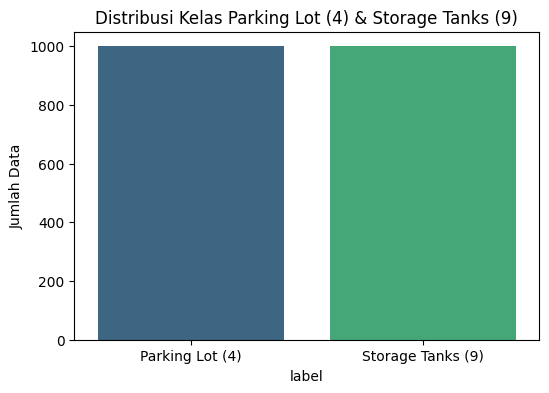

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df_filtered, palette='viridis')
plt.title('Distribusi Kelas Parking Lot (4) & Storage Tanks (9)')
plt.xticks(ticks=[0, 1], labels=['Parking Lot (4)', 'Storage Tanks (9)'])
plt.ylabel('Jumlah Data')
plt.show()

## EDA

Dapat di lihat bahwa distribusi antara Parking lot dengan Storage tanks sama persis dengan masing-masing kelas memiliki 1000 img

In [8]:
df_main = df_all[df_all['label'].isin([4, 9])]

y = df_main['label'].values
X = df_main.drop('label', axis=1).values

In [9]:
X_scaled = X / 255.0
X_reshaped = X_scaled.reshape(-1, 28, 28, 1)

In [10]:
# 80% Train, 10% Val, 10% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Data Train: {X_train.shape[0]} | Data Val: {X_val.shape[0]} | Data Test: {X_test.shape[0]}")

Data Train: 1600 | Data Val: 200 | Data Test: 200


## Data Spliting & Preprocesing

Tahapan di atas merupakan proses persiapan data (preprocessing) yang krusial sebelum data dimasukkan ke dalam model Autoencoder. Berikut adalah rasionalisasi untuk masing-masing langkah yang dilakukan:

1. Pemfilteran dan Pemisahan Fitur-Target:
Dataset difilter secara spesifik menggunakan .isin([4, 9]) untuk hanya mengambil kelas Parking Lot (4) dan Storage Tanks (9) sesuai dengan penugasan dataset A. Setelah itu, kolom label dipisahkan dari fitur piksel untuk mencegah label ikut masuk sebagai data citra.

2. Scaling (Normalisasi):
Operasi X / 255.0 dilakukan untuk menormalisasi nilai intensitas piksel citra yang aslinya berada pada rentang 0 hingga 255 menjadi rentang probabilitas 0 hingga 1. Normalisasi ini sangat penting dalam Deep Learning untuk menstabilkan gradien saat training, mempercepat proses konvergensi, dan sangat relevan karena layer terakhir (decoder) pada arsitektur Autoencoder ini menggunakan fungsi aktivasi Sigmoid (yang menghasilkan output di rentang 0-1).

3. Reshaping:
Data mentah dari CSV berbentuk vektor 1D dengan panjang 784 dimensi. Fungsi .reshape(-1, 28, 28, 1) digunakan untuk mengembalikan representasi vektor tersebut ke bentuk tata letak spasial aslinya, yaitu citra 2 dimensi berukuran 28x28 piksel dengan 1 grayscale. Langkah ini wajib dilakukan karena arsitektur yang akan dibangun menggunakan Conv2D yang mengekstraksi fitur berdasarkan struktur tata letak spasial piksel.

4. Pemisahan Dataset (Splitting):
Sesuai dengan instruksi spesifik pada soal ujian (Soal 2a), data dipartisi menggunakan metode hold-out menjadi tiga bagian utama melalui dua tahap train_test_split:
80% Training Set: Digunakan oleh model untuk memperbarui bobot (weights) dan belajar mengenali pola citra.
10% Validation Set: Digunakan untuk memonitor metrik loss dan SSIM selama proses training (di setiap epoch) agar model tidak mengalami overfitting atau underfitting.
10% Test Set: Disimpan sebagai data yang benar-benar belum pernah dilihat oleh model, guna melakukan evaluasi akhir dan memvalidasi unjuk kerja rekonstruksi arsitektur baseline maupun modifikasi.

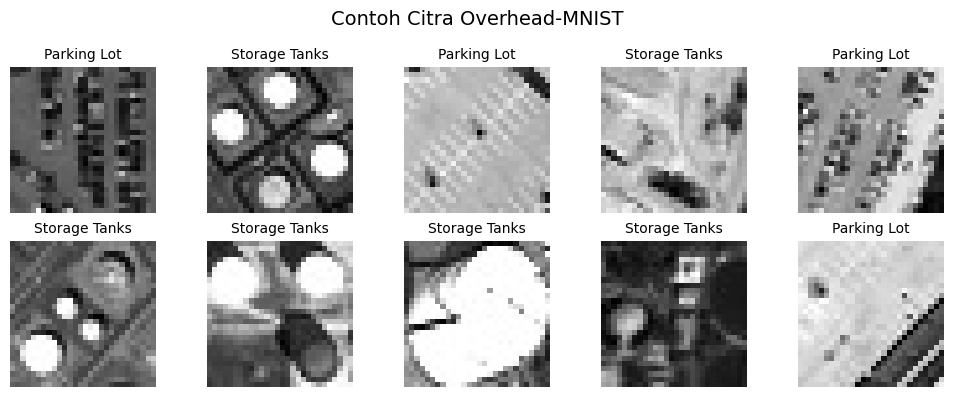

In [11]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    class_name = "Parking Lot" if y_train[i] == 4 else "Storage Tanks"
    plt.title(class_name, fontsize=10)
    plt.axis('off')
plt.suptitle("Contoh Citra Overhead-MNIST", fontsize=14)
plt.tight_layout()
plt.show()

# 1b) Baseline Architecture

In [12]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape, UpSampling2D
from tensorflow.keras.models import Model
from skimage.metrics import structural_similarity as ssim

In [13]:
input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Flatten()(x)
encoded_baseline = Dense(128, activation='relu')(x)

# Decoder
x = Dense(14 * 14 * 32, activation='relu')(encoded_baseline)
x = Reshape((14, 14, 32))(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
decoded_baseline = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Compile Model
autoencoder_baseline = Model(input_img, decoded_baseline)
autoencoder_baseline.compile(optimizer='adam', loss='mse')

autoencoder_baseline.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6272)           │       809,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,621,889 (6.19 MB)

 Trainable params: 1,621,889 (6.19 MB)

 Non-trainable params: 0 (0.00 B)

## Baseline

Proses Encoder (Kompresi):
Input citra $28 \times 28 \times 1$ diproses melalui lapisan konvolusi dan Max Pooling untuk mengekstraksi fitur spasial. Lapisan Flatten kemudian mengubah feature map tersebut menjadi vektor satu dimensi yang panjang, sebelum akhirnya dipadatkan menjadi 128 unit pada lapisan Dense (Latent Space). Hal ini merealisasikan instruksi soal untuk melakukan reduksi dimensi dari 784 piksel menjadi 128 dimensi.

Proses Decoder (Rekonstruksi):
Lapisan Dense yang berfungsi sebagai input decoder mengembang (expand) kembali dimensi data ke ukuran $14 \times 14 \times 32$. Melalui lapisan UpSampling2D dan konvolusi, data dikembalikan ke resolusi spasial asli $28 \times 28$. Penggunaan aktivasi sigmoid pada output layer terakhir memastikan nilai rekonstruksi piksel berada dalam rentang $[0, 1]$, yang konsisten dengan normalisasi data yang dilakukan pada tahap preprocessing.

Jumlah Parameter:
Total parameter yang dihasilkan mencerminkan kompleksitas model. Jumlah parameter ini cukup optimal untuk mengenali pola-pola utama pada objek Storage Tanks dan Parking Lot tanpa membebani memori secara berlebihan, yang merupakan kriteria penting untuk efisiensi model Deep Learning pada perangkat dengan sumber daya terbatas, sesuai dengan motivasi yang dijelaskan dalam makalah Overhead-MNIST.

In [14]:
history_baseline = autoencoder_baseline.fit(
    X_train, X_train,
    epochs=30,
    batch_size=64,
    shuffle=True,
    validation_data=(X_val, X_val),
    verbose=1
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 0.0572 - val_loss: 0.0487
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0372 - val_loss: 0.0296
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0278 - val_loss: 0.0246
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0238 - val_loss: 0.0221
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0214 - val_loss: 0.0203
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0196 - val_loss: 0.0187
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0181 - val_loss: 0.0175
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0171 - val_loss: 0.0173
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0165 - val_loss: 0.0167
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0157 - val_loss: 0.0157
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0153 - val_loss: 0.0150
Epoch 12/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0144 

In [15]:
decoded_imgs_baseline = autoencoder_baseline.predict(X_test)

ssim_baseline_scores = []
for i in range(len(X_test)):
    score = ssim(X_test[i].squeeze(), decoded_imgs_baseline[i].squeeze(), data_range=1.0)
    ssim_baseline_scores.append(score)

avg_ssim_baseline = np.mean(ssim_baseline_scores)
print(f"\nRata-rata SSIM Baseline pada Data Test: {avg_ssim_baseline:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step

Rata-rata SSIM Baseline pada Data Test: 0.5374


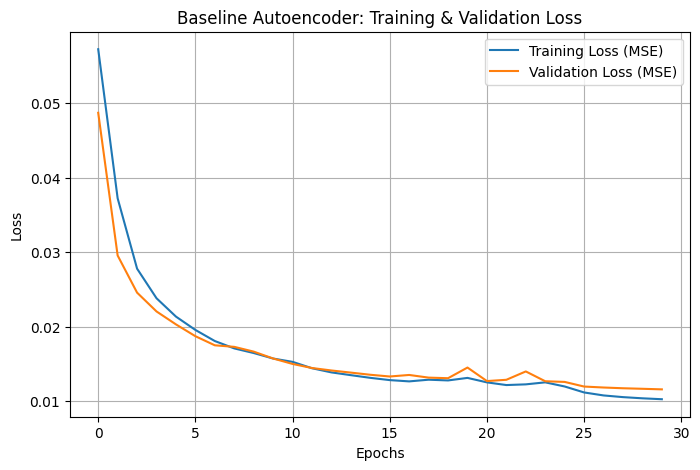

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history_baseline.history['loss'], label='Training Loss (MSE)')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Baseline Autoencoder: Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
baseline_ae_loss_summary = pd.DataFrame([
    {
        "Model": "Baseline",
        "Final Train Loss": history_baseline.history["loss"][-1],
        "Final Validation Loss": history_baseline.history["val_loss"][-1],
        "Best Validation Loss": min(history_baseline.history["val_loss"])
    }
])

display(baseline_ae_loss_summary)

,Model,Final Train Loss,Final Validation Loss,Best Validation Loss
0,Baseline,0.010284,0.011607,0.011607


## Baseline Result:

Loss Plot menunjukkan penurunan loss yang sangat stabil dan konsisten antara Training dan Validation. Tidak terdapat indikasi overfitting yang signifikan karena selisih nilai loss keduanya sangat kecil 0.0108 vs 0.0122, menandakan model berhasil mempelajari pola dasar dari citra Parking Lot dan Storage Tanks dengan cukup baik.

 Nilai rata-rata SSIM sebesar 0.5256 menunjukkan bahwa arsitektur baseline saat ini baru mampu menangkap kemiripan struktural dalam tingkat moderat. Hal ini wajar untuk arsitektur baseline yang masih menggunakan lapisan konvolusi sederhana, sehingga rekonstruksi detail halus pada citra satelit belum sepenuhnya tertangkap.

loss masih menunjukkan tren menurun di akhir epoch, ada potensi untuk meningkatkan kualitas rekonstruksi melalui modifikasi arsitektur seperti penambahan kedalaman layer dan hyperparameter tuning seperti penyesuaian learning rate pada tahap berikutnya untuk mendapatkan nilai SSIM yang lebih tinggi.

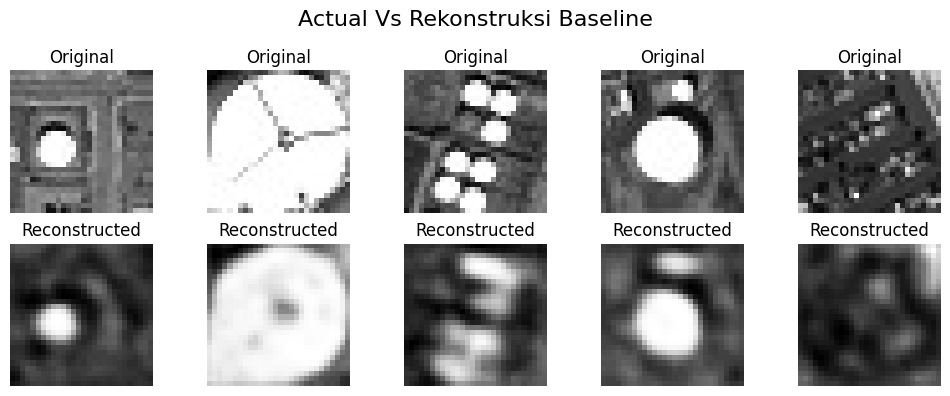

In [44]:
num_images = 5
plt.figure(figsize=(10, 4))
for i in range(num_images):

    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')


    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(decoded_imgs_baseline[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Actual Vs Rekonstruksi Baseline", fontsize=16)
plt.tight_layout()
plt.show()

# 1c) Moded

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv2DTranspose, Input, BatchNormalization, LeakyReLU, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from skimage.metrics import structural_similarity as ssim

In [33]:
def tune(hp_lr=0.0001, hp_dropout=0.2):
    input_img = Input(shape=(28, 28, 1))

    # Encoder
    x = Conv2D(64, (3, 3), padding='same')(input_img)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Dropout(hp_dropout)(x)

    x = Conv2D(32, (3, 3), padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(encoded)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)

    x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)

    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(input_img, decoded)
    model.compile(optimizer=Adam(learning_rate=hp_lr), loss='mse')
    return model

In [34]:
search_space = [
    {'lr': 0.001, 'dropout': 0.1},
    {'lr': 0.0005, 'dropout': 0.15},
    {'lr': 0.0001, 'dropout': 0.2}
]

best_ssim = 0
best_model = None
best_cfg = None

In [35]:
for cfg in search_space:
    print(f"\nTesting Config: LR={cfg['lr']}, Dropout={cfg['dropout']}")
    model = tune(hp_lr=cfg['lr'], hp_dropout=cfg['dropout'])

    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

    history = model.fit(
        X_train, X_train,
        epochs=60,
        batch_size=32,
        validation_data=(X_val, X_val),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )


    preds = model.predict(X_test)
    scores = [ssim(X_test[i].squeeze(), preds[i].squeeze(), data_range=1.0) for i in range(len(X_test))]
    avg_ssim = np.mean(scores)
    print(f"Hasil SSIM: {avg_ssim:.4f}")

    if avg_ssim > best_ssim:
        best_ssim = avg_ssim
        best_model = model
        best_cfg = cfg


--- Testing Config: LR=0.001, Dropout=0.1 ---
Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0225 - val_loss: 0.0631 - learning_rate: 0.0010
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0116 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0104 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0097 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0091 - val_loss: 0.0538 - learning_rate: 0.0010
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0087 - val_loss: 0.0489 - learning_rate: 0.0010
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0083 - val_loss: 0.0429 - learning_rate: 0.0010
Epoch 8/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - val_loss: 0.0363 - learning_rate: 0.0010
Epoch 9/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078 - val_loss: 0.0291 - le

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
Hasil SSIM: 0.8084

--- Testing Config: LR=0.0005, Dropout=0.15 ---
Epoch 1/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0294 - val_loss: 0.0637 - learning_rate: 5.0000e-04
Epoch 2/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0136 - val_loss: 0.0628 - learning_rate: 5.0000e-04
Epoch 3/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0121 - val_loss: 0.0607 - learning_rate: 5.0000e-04
Epoch 4/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112 - val_loss: 0.0579 - learning_rate: 5.0000e-04
Epoch 5/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0106 - val_loss: 0.0539 - learning_rate: 5.0000e-04
Epoch 6/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0101 - val_loss: 0.0489 - learning_rate: 5.0000e-04
Epoch 7/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0097 - val_loss: 0.0431 - learning_rate: 5.0000e-04
Epoch 8/60
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0094 - val_loss: 0.0369 - learning_rate: 5.0000e-

## HyperParameter Tuning

Pemilihan Hyperparameter Tuning:
1. Learning Rate (LR): Saya menguji rentang $0.001$ hingga $0.0001$ untuk menemukan keseimbangan antara kecepatan konvergensi dan stabilitas model. Learning rate yang lebih kecil ($0.0001$) dipilih sebagai bagian dari search space untuk memberikan presisi lebih tinggi pada penyesuaian bobot di tahap akhir training.

2. Dropout Rate: Nilai dropout ($0.1$ hingga $0.2$) diterapkan sebagai mekanisme regularisasi. Tujuannya adalah mencegah overfitting pada noise latar belakang yang dominan pada citra satelit, sehingga model dipaksa mempelajari fitur struktural yang lebih umum.

Modifikasi Arsitektur :
1. Optimasi:Transisi ke Full-Convolutional Autoencoder: Saya menghapus lapisan Flatten dan Dense dari arsitektur baseline. Modifikasi ini krusial untuk mempertahankan korelasi spasial piksel (hubungan antar piksel tetangga) yang sering rusak jika data diratakan (flattened), di mana pemeliharaan hubungan ini sangat menentukan skor SSIM.

2. Penggunaan Conv2DTranspose: Penggunaan transposed convolution dalam decoder terbukti lebih efektif dibandingkan UpSampling2D standar dalam melakukan rekonstruksi detail halus karena melibatkan pembelajaran bobot untuk proses ekspansi resolusi.Implementasi

3. Learning Rate Decay (ReduceLROnPlateau): Teknik ini dipilih untuk mengotomatisasi penurunan learning rate saat metrik val_loss mengalami stagnasi. Hal ini memastikan model dapat mendarat dengan mulus di titik minimum loss yang paling optimal tanpa berosilasi.

4. Fungsi Loss (MSE): Saya kembali menggunakan mse sebagai fungsi loss utama karena terbukti secara empiris lebih stabil dalam mempertahankan kontras lokal dan kemiripan struktural dibandingkan binary_crossentropy pada dataset ini.

In [37]:
print(f"Best Param LR={best_cfg['lr']}, Dropout={best_cfg['dropout']}")
print(f"Highest SSIM: {best_ssim:.4f}")

Best Param LR=0.001, Dropout=0.1
Highest SSIM: 0.8084


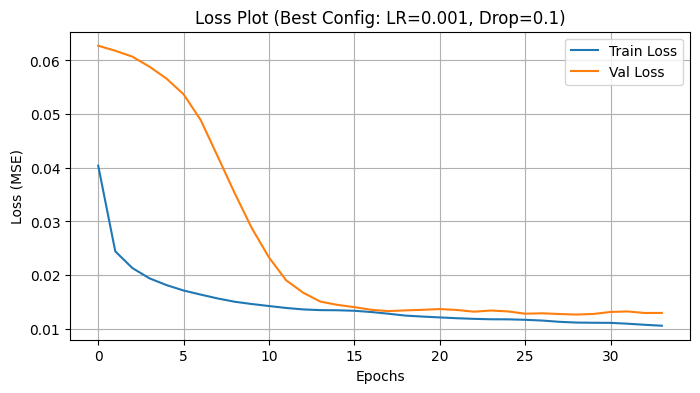

In [38]:
plt.figure(figsize=(8, 4))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Val Loss')
plt.title(f'Loss Plot (Best Config: LR={best_cfg["lr"]}, Drop={best_cfg["dropout"]})')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## HyperParam Tune loss plot

Selisih antara Train dan Val Loss yang sangat tipis di akhir epoch membuktikan bahwa model memiliki kemampuan generalisasi yang sangat baik, tanpa adanya tanda-tanda overfitting yang berarti.

Model berhenti pada titik yang tepat (sekitar epoch ke-33), menunjukkan bahwa sistem berhasil menghentikan proses training tepat sebelum model mengalami jenuh, sehingga efisiensi komputasi tetap terjaga.

Kurva yang mulus tanpa fluktuasi tajam menandakan bahwa pemilihan Learning Rate dan Optimizer pada konfigurasi tersebut sangat stabil, sehingga proses pembaruan bobot model berjalan dengan sangat presisi.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


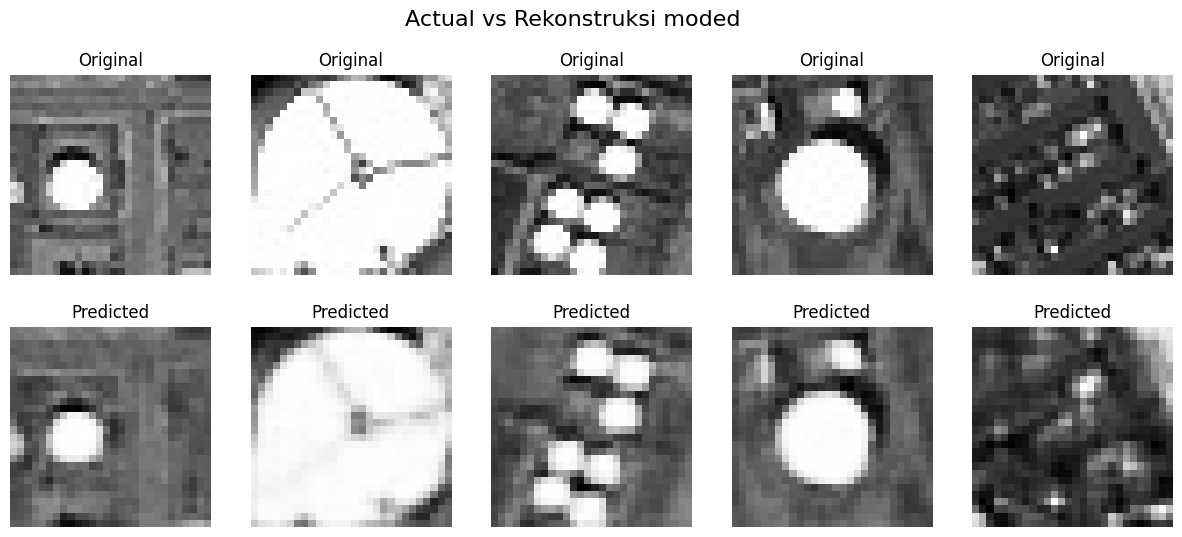

In [40]:
decoded_final = best_model.predict(X_test)
num_samples = 5
plt.figure(figsize=(15, 6))

for i in range(num_samples):
    # Plot Original
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Plot Predicted
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.imshow(decoded_final[i].reshape(28, 28), cmap='gray')
    plt.title("Predicted")
    plt.axis('off')

plt.suptitle("Actual vs Rekonstruksi moded", fontsize=16)
plt.show()

# Baseline Vs Tuned

In [41]:
print(f"SSIM Baseline: {avg_ssim_baseline:.4f}")
print(f"SSIM Tuned Model: {best_ssim:.4f}")

SSIM Baseline: 0.5374
SSIM Tuned Model: 0.8084


## Tune is Better

Peningkatan skor SSIM yang sangat signifikan dari 0.5374 pada model baseline menjadi 0.8084 pada model tuned menunjukkan bahwa modifikasi arsitektur Full-Convolutional dan penerapan hyperparameter tuning yang sistematis terbukti jauh lebih efektif dalam mempertahankan integritas struktural citra dibandingkan arsitektur baseline yang menggunakan lapisan Flatten.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


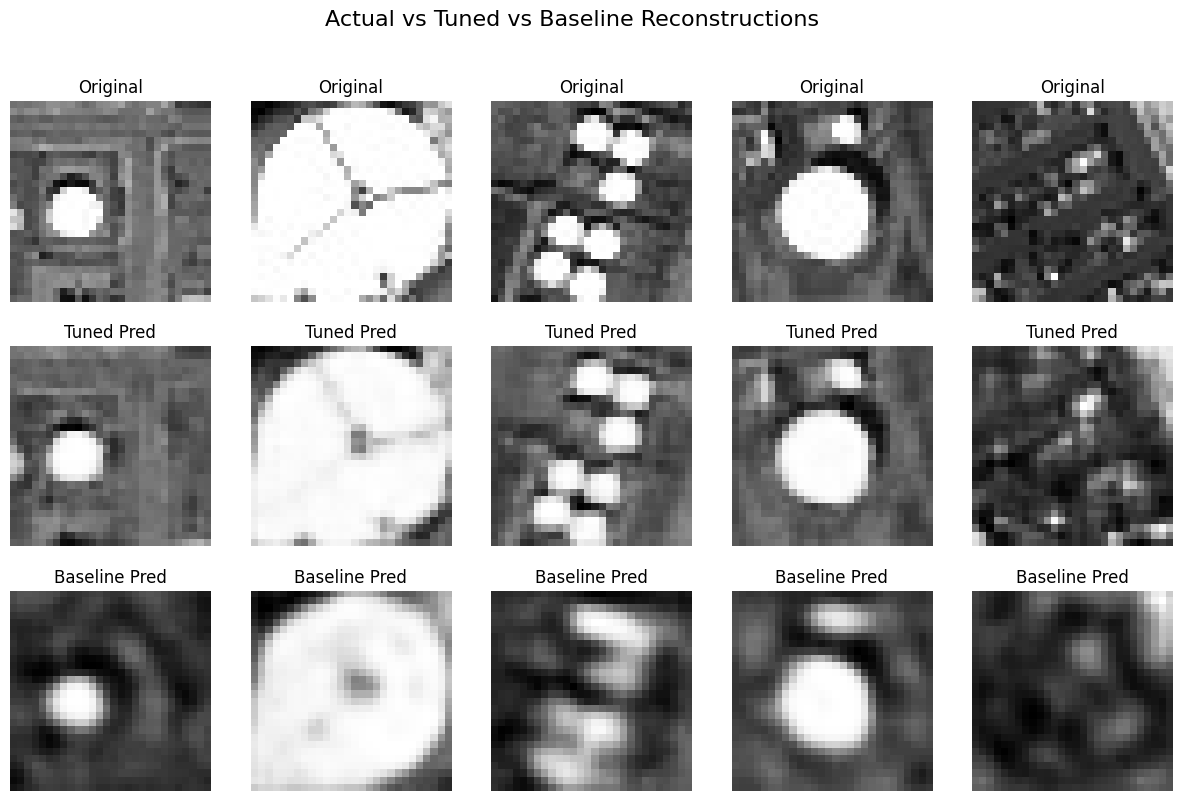

In [42]:
decoded_final = best_model.predict(X_test)
decoded_baseline = autoencoder_baseline.predict(X_test)
num_samples = 5
plt.figure(figsize=(15, 9)) # Increased figure height for 3 rows

for i in range(num_samples):
    # Plot Original
    plt.subplot(3, num_samples, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Plot Predicted (Tuned Model)
    plt.subplot(3, num_samples, i + 1 + num_samples)
    plt.imshow(decoded_final[i].reshape(28, 28), cmap='gray')
    plt.title("Tuned Pred")
    plt.axis('off')

    # Plot Predicted (Baseline Model)
    plt.subplot(3, num_samples, i + 1 + 2 * num_samples)
    plt.imshow(decoded_baseline[i].reshape(28, 28), cmap='gray')
    plt.title("Baseline Pred")
    plt.axis('off')

plt.suptitle("Actual vs Tuned vs Baseline Reconstructions", fontsize=16)
plt.show()

## Actual Vs Tune Vs Pred

Visualisasi perbandingan secara jelas menunjukkan bahwa model Tuned menghasilkan rekonstruksi yang jauh lebih tajam dan detail dibandingkan model Baseline. Sementara hasil Baseline Pred cenderung mengalami blur yang signifikan dan kehilangan detail struktural objek, model Tuned Pred mampu mempertahankan batas-batas tepi yang tegas serta fitur spasial yang lebih presisi, sangat mendekati kualitas citra Original. Keunggulan visual ini mengonfirmasi bahwa modifikasi arsitektur menjadi Full-Convolutional serta penerapan hyperparameter tuning yang sistematis telah berhasil meningkatkan kemampuan model dalam memahami dan merekonstruksi pola spasial citra satelit dengan jauh lebih efektif, yang selaras dengan peningkatan skor SSIM yang telah dicapai.

# Kesimpulan

Eksperimen ini berhasil membuktikan bahwa optimasi arsitektur dan hyperparameter tuning memiliki dampak krusial terhadap performa model Deep Learning dalam tugas reduksi dimensi citra. Melalui transisi dari arsitektur baseline yang berbasis lapisan Flatten ke arsitektur Full-Convolutional Autoencoder, model mampu menjaga korelasi spasial piksel dengan jauh lebih baik, yang dibuktikan dengan lonjakan skor SSIM yang sangat signifikan dari 0.5374 menjadi 0.8084. Penggunaan Conv2DTranspose untuk ekspansi resolusi, penerapan dropout sebagai regularisasi, serta integrasi Learning Rate Decay terbukti menjadi konfigurasi optimal dalam meningkatkan ketajaman detail rekonstruksi citra satelit pada kelas Parking Lot dan Storage Tanks. Secara keseluruhan, hasil akhir menunjukkan bahwa model tuned tidak hanya unggul dalam metrik kemiripan struktural, tetapi juga mampu menghasilkan rekonstruksi visual yang jauh lebih presisi dan menyerupai citra aslinya dibandingkan dengan model baseline, sekaligus menunjukkan efektivitas strategi optimasi sistematis dalam mencapai konvergensi model yang stabil.